# Week 6 Day 6 – Time Series Mini Project

## Objective

Forecast the **Nifty 50 monthly closing price** for the next **6 months** using an **ARIMA(1,1,1)** model.

### Tasks
- Load cleaned Nifty 50 dataset
- Convert daily data into monthly closing prices
- Fit an ARIMA model
- Forecast the next 6 months
- Plot historical data, forecast, and confidence intervals
- Interpret the results

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

## Step 1: Load Dataset


In [2]:
import yfinance as yf

nifty = yf.download("^NSEI", start="2019-01-01", end="2025-01-01")

nifty.to_csv("cleaned_nifty50.csv")

[*********************100%***********************]  1 of 1 completed


In [ ]:
# # Load cleaned dataset

# nifty = pd.read_csv(
#     "cleaned_nifty50.csv",
#     parse_dates=["Date"],
#     index_col="Date"
# )

# # Display first five rows

# nifty.head()

## Step 2: Convert Daily Data to Monthly Data

Use the last trading day's closing price for every month.

In [6]:
# Resample daily prices into monthly closing prices

monthly_close = nifty["Close"].resample("M").last()

# Display first few values

monthly_close.head(), 

C:\Users\Ms642\AppData\Local\Temp\ipykernel_8872\1851852832.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = nifty["Close"].resample("M").last()


(Ticker             ^NSEI
 Date                    
 2019-01-31  10830.950195
 2019-02-28  10792.500000
 2019-03-31  11570.000000
 2019-04-30  11748.150391
 2019-05-31  11922.799805,)

## Step 3: Visualize Monthly Closing Prices

Plot the monthly closing prices before forecasting.

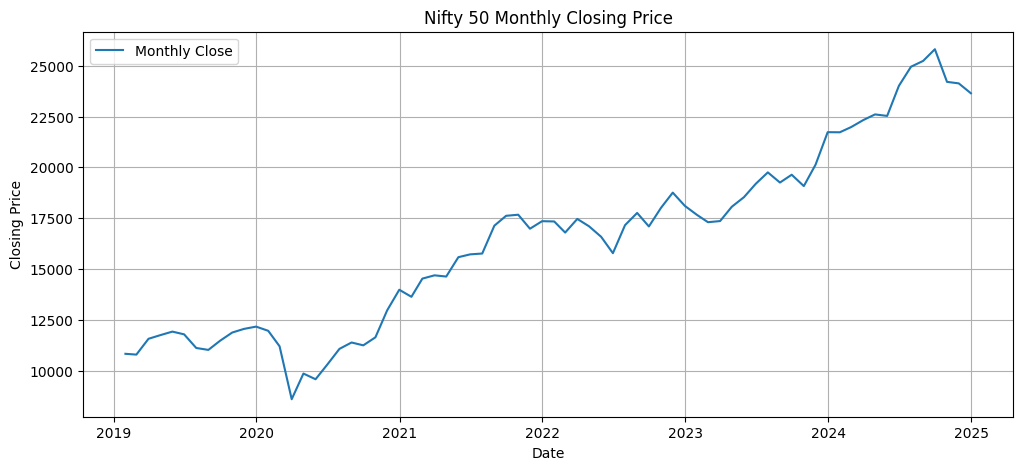

In [7]:
# Create figure

plt.figure(figsize=(12,5))

# Plot monthly closing price

plt.plot(monthly_close, label="Monthly Close")

# Add title

plt.title("Nifty 50 Monthly Closing Price")

# Axis labels

plt.xlabel("Date")
plt.ylabel("Closing Price")

# Show legend

plt.legend()

# Enable grid

plt.grid(True)

# Save figure

plt.savefig(
    "../images/monthly_close.png",
    dpi=300,
    bbox_inches="tight"
)

# Display plot

plt.show()

## Step 4: Build ARIMA Model

Fit an ARIMA(1,1,1) model to the monthly closing prices.

In [8]:
# Create ARIMA model

model = ARIMA(
    monthly_close,
    order=(1,1,1)
)

# Fit model

model_fit = model.fit()

# Display summary

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  ^NSEI   No. Observations:                   72
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -567.919
Date:                Thu, 09 Jul 2026   AIC                           1141.838
Time:                        18:55:19   BIC                           1148.626
Sample:                    01-31-2019   HQIC                          1144.537
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.009    113.170      0.000       0.983       1.017
ma.L1         -0.9979      0.136     -7.319      0.000      -1.265      -0.731
sigma2      5.154e+05   2.76e-07   1.87e+12      0.0

## Step 5: Forecast the Next Six Months

Generate six months of future monthly closing prices along with confidence intervals.

In [9]:
# Forecast next six months

forecast = model_fit.get_forecast(steps=6)

# Predicted values

forecast_mean = forecast.predicted_mean

# Confidence intervals

confidence = forecast.conf_int()

# Display forecast

forecast_mean

2025-01-31    23806.944807
2025-02-28    23969.077532
2025-03-31    24131.198958
2025-04-30    24293.309086
2025-05-31    24455.407916
2025-06-30    24617.495448
Freq: ME, Name: predicted_mean, dtype: float64

## Step 6: Plot Historical Data and Forecast

Compare historical prices with forecasted prices and visualize the 95% confidence interval.

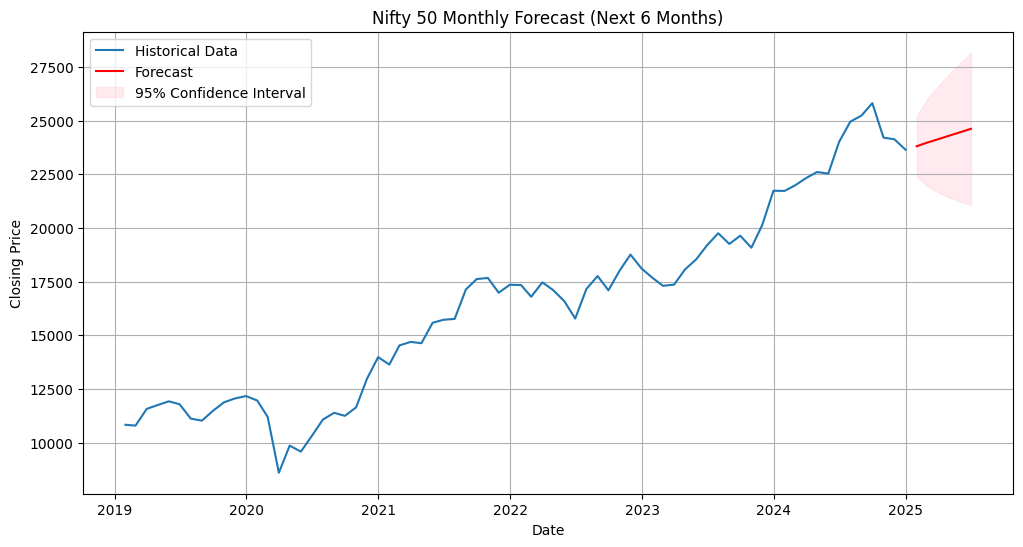

In [10]:
# Create figure

plt.figure(figsize=(12,6))

# Plot historical data

plt.plot(
    monthly_close,
    label="Historical Data"
)

# Plot forecast

plt.plot(
    forecast_mean,
    color="red",
    label="Forecast"
)

# Plot confidence interval

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

# Title

plt.title("Nifty 50 Monthly Forecast (Next 6 Months)")

# Axis labels

plt.xlabel("Date")
plt.ylabel("Closing Price")

# Legend

plt.legend()

# Grid

plt.grid(True)

# Save image

plt.savefig(
    "../images/forecast.png",
    dpi=300,
    bbox_inches="tight"
)

# Show plot

plt.show()

## Step 7: Display Forecast Table

Display the forecast values together with their lower and upper confidence limits.

In [11]:
# Create forecast DataFrame

forecast_df = pd.DataFrame({

    "Forecast": forecast_mean,

    "Lower CI": confidence.iloc[:,0],

    "Upper CI": confidence.iloc[:,1]

})

# Display forecast

forecast_df

,Forecast,Lower CI,Upper CI
2025-01-31,23806.944807,22394.380605,25219.509008
2025-02-28,23969.077532,21961.600275,25976.554789
2025-03-31,24131.198958,21660.593366,26601.804550
2025-04-30,24293.309086,21426.755611,27159.862561
2025-05-31,24455.407916,21235.208313,27675.607518
2025-06-30,24617.495448,21073.264644,28161.726253


# Interpretation

The ARIMA(1,1,1) model forecasts the monthly closing prices of the Nifty 50 index for the next six months. The red line represents the predicted prices, while the shaded region indicates the 95% confidence interval. As the forecast moves further into the future, the confidence interval becomes wider, indicating increased uncertainty in the predictions.

# Caveat

The ARIMA model relies only on historical price data and assumes that past patterns continue into the future. It does not account for macroeconomic conditions, company performance, government policies, global events, investor sentiment, or unexpected market shocks. Therefore, this forecast is intended for educational purposes only and should **not** be used as the sole basis for real trading or investment decisions.